In [72]:
pip install Faker

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import pandas as pd
import random
from faker import Faker

fake = Faker()

# Crops list
crops = [
    "Rice", "Wheat", "Tomato", "Potato", "Onion",
    "Carrot", "Cabbage", "Banana", "Mango", "Corn",
    "Chilli", "Sugarcane", "Cotton", "Groundnut", "Beans"
]

# Months
months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Indian states
states = [
    "Kerala", "Tamil Nadu", "Karnataka", "Maharashtra",
    "Punjab", "Gujarat", "Andhra Pradesh", "Telangana",
    "Uttar Pradesh", "Rajasthan"
]

# Demand levels
demand_levels = ["Low", "Medium", "High"]

# Create empty list
data = []

# Generate 2000 rows
for i in range(2000):

    crop = random.choice(crops)
    month = random.choice(months)
    state = random.choice(states)
    demand = random.choice(demand_levels)

    # Generate market price based on demand
    if demand == "Low":
        price = round(random.uniform(10, 30), 2)

    elif demand == "Medium":
        price = round(random.uniform(30, 70), 2)

    else:
        price = round(random.uniform(70, 150), 2)

    # Create row
    row = {
        "Year": 2025,
        "Crop_Name": crop,
        "Month": month,
        "Market_Price_per_kg": price,
        "Demand": demand,
        "State": state
    }

    data.append(row)

# Convert to DataFrame
df = pd.DataFrame(data)

# Save CSV
df.to_csv("market_price_dataset_2025.csv", index=False)

# Show first 10 rows
print(df.head(10))

print("\nDataset Generated Successfully!")

   Year  Crop_Name      Month  Market_Price_per_kg  Demand           State
0  2025  Sugarcane       July                54.25  Medium          Kerala
1  2025    Cabbage      April                27.82     Low  Andhra Pradesh
2  2025       Corn   December                23.25     Low         Gujarat
3  2025     Carrot      March                84.82    High         Gujarat
4  2025      Mango   November                59.71  Medium       Karnataka
5  2025     Potato  September                42.53  Medium       Rajasthan
6  2025     Potato   December                41.97  Medium       Telangana
7  2025  Sugarcane       July                64.45  Medium       Rajasthan
8  2025    Cabbage   December                15.95     Low      Tamil Nadu
9  2025       Corn    October                14.91     Low  Andhra Pradesh

Dataset Generated Successfully!


In [75]:
df.describe()

,Year,Market_Price_per_kg
count,2000.0,2000.000000
mean,2025.0,59.235770
std,0.0,39.615324
min,2025.0,10.000000
25%,2025.0,25.277500
50%,2025.0,50.475000
75%,2025.0,87.135000
max,2025.0,149.690000


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 2000 non-null   int64  
 1   Crop_Name            2000 non-null   object 
 2   Month                2000 non-null   object 
 3   Market_Price_per_kg  2000 non-null   float64
 4   Demand               2000 non-null   object 
 5   State                2000 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 93.9+ KB


In [77]:
df.isnull().sum()

Year                   0
Crop_Name              0
Month                  0
Market_Price_per_kg    0
Demand                 0
State                  0
dtype: int64

In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
import pandas as pd

In [80]:
df = pd.read_csv("market_price_dataset_2025.csv")
df 

,Year,Crop_Name,Month,Market_Price_per_kg,Demand,State
0,2025,Sugarcane,July,54.25,Medium,Kerala
1,2025,Cabbage,April,27.82,Low,Andhra Pradesh
2,2025,Corn,December,23.25,Low,Gujarat
3,2025,Carrot,March,84.82,High,Gujarat
4,2025,Mango,November,59.71,Medium,Karnataka
...,...,...,...,...,...,...
1995,2025,Mango,January,39.66,Medium,Maharashtra
1996,2025,Rice,August,36.46,Medium,Kerala
1997,2025,Carrot,April,47.34,Medium,Gujarat
1998,2025,Carrot,September,15.95,Low,Uttar Pradesh


In [81]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

In [82]:
df["Crop_Name"] = LabelEncoder().fit_transform(df["Crop_Name"])
df["Month"] = LabelEncoder().fit_transform(df["Month"])
df["Demand"] = LabelEncoder().fit_transform(df["Demand"])
df["State"] = LabelEncoder().fit_transform(df["State"]) 

In [83]:
X = df[["Crop_Name","Month","Demand","State"]]
y = df["Market_Price_per_kg"]

In [84]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [85]:
lr = LinearRegression() 
lr_model = lr.fit(X_train,y_train)
lr_pred = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test,lr_pred)
lr_r2 = r2_score(y_test,lr_pred)


print("Linear Regression")
print("MAE:", lr_mae)
print("R2 Score:", lr_r2)

Linear Regression
MAE: 28.994369129733496
R2 Score: 0.3562917272895155


In [86]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
    )
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)


print("\nRandom Forest")
print("MAE:", rf_mae)
print("R2 Score:", rf_r2)


Random Forest
MAE: 12.323789674503963
R2 Score: 0.8360957758336163


In [87]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_r2 = r2_score(y_test, xgb_pred)

print("\nXGBoost")
print("MAE:", xgb_mae)
print("R2 Score:", xgb_r2)


XGBoost
MAE: 12.216523417186735
R2 Score: 0.8336159416567811


In [88]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "R2 Score": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

print(results)

               Model        MAE  R2 Score
0  Linear Regression  28.994369  0.356292
1      Random Forest  12.323790  0.836096
2            XGBoost  12.216523  0.833616


In [89]:
best_model = results.sort_values(
    by="R2 Score",
    ascending=False
)

print(best_model)

               Model        MAE  R2 Score
1      Random Forest  12.323790  0.836096
2            XGBoost  12.216523  0.833616
0  Linear Regression  28.994369  0.356292


In [90]:
import pickle

with open("randonforest_market_price_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

print("Model Saved!")

Model Saved!


In [91]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
df2 = pd.read_csv("market_price_dataset_2025.csv")

tomato_df = df2[df2["Crop_Name"] == "Tomato"]

print(tomato_df.head())

     Year Crop_Name     Month  Market_Price_per_kg  Demand        State
32   2025    Tomato       May                67.38  Medium    Karnataka
99   2025    Tomato      June                13.92     Low       Kerala
103  2025    Tomato   October                25.49     Low    Telangana
104  2025    Tomato  December                24.47     Low  Maharashtra
105  2025    Tomato    August                75.20    High       Kerala


In [93]:
month_map = {
    "January": "2025-01-01",
    "February": "2025-02-01",
    "March": "2025-03-01",
    "April": "2025-04-01",
    "May": "2025-05-01",
    "June": "2025-06-01",
    "July": "2025-07-01",
    "August": "2025-08-01",
    "September": "2025-09-01",
    "October": "2025-10-01",
    "November": "2025-11-01",
    "December": "2025-12-01"
}

tomato_df["ds"] = tomato_df["Month"].map(month_map)

tomato_df["ds"] = pd.to_datetime(tomato_df["ds"])

tomato_df["y"] = tomato_df["Market_Price_per_kg"]

tomato_df = tomato_df[["ds", "y"]]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10636\92323480.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tomato_df["ds"] = tomato_df["Month"].map(month_map)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10636\92323480.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tomato_df["ds"] = pd.to_datetime(tomato_df["ds"])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10636\92323480.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [94]:
from prophet import Prophet

model = Prophet()

model.fit(tomato_df)

10:53:03 - cmdstanpy - INFO - Chain [1] start processing
10:53:03 - cmdstanpy - INFO - Chain [1] done processing


In [95]:
future = model.make_future_dataframe(periods=6, freq='M')

forecast = model.predict(future)

print(forecast[["ds", "yhat"]].tail())

           ds       yhat
13 2026-01-31  64.378275
14 2026-02-28  65.212927
15 2026-03-31  66.137007
16 2026-04-30  67.031278
17 2026-05-31  67.955357


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


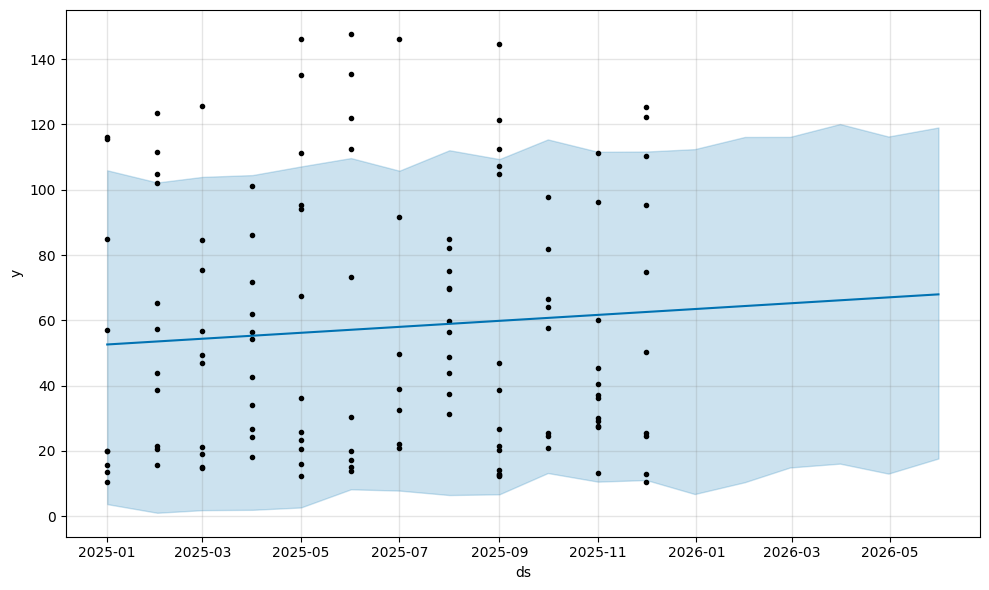

In [96]:
fig = model.plot(forecast)